# Module 5: Anomaly Detection Classifier
## AeroNet Lite — Autonomous Drone Delivery Simulation

**Owner:** Saad

This notebook builds an anomaly detection classifier to identify abnormal drone behaviors during delivery operations.

### Objectives
1. Generate synthetic anomaly data based on simulation rules
2. Engineer features: battery_drop, route_deviation, speed_jump, altitude_jump
3. Train Decision Tree and Random Forest classifiers
4. Evaluate with accuracy and confusion matrix
5. Save `anomaly_predictions.csv` for the simulator

### Anomaly Classes
- **Normal:** All metrics within bounds
- **Battery:** High battery drain (battery_drop > 8%)
- **Route:** Unexpected path deviation (route_deviation > 2 cells)
- **Sensor:** Sensor errors (speed_jump > 0.6 or altitude_jump > 0.6)

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost

  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import csv

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 1: Generate Synthetic Anomaly Data

Create a synthetic dataset with features and labels based on drone telemetry simulation rules.

In [5]:
# Generate synthetic anomaly training data
np.random.seed(42)

n_samples = 1000

# Features
battery_drop = np.random.exponential(scale=3, size=n_samples)  # % per step
route_deviation = np.random.exponential(scale=0.8, size=n_samples)  # cells
speed_jump = np.random.uniform(0, 1, n_samples)  # normalized
altitude_jump = np.random.uniform(0, 1, n_samples)  # normalized

# Labels based on thresholds
labels = []
for i in range(n_samples):
    bd, rd, sj, aj = battery_drop[i], route_deviation[i], speed_jump[i], altitude_jump[i]
    
    # Priority: Battery > Route > Sensor > Normal
    if bd > 8.0:
        label = "Battery"
    elif rd > 2.0:
        label = "Route"
    elif sj > 0.6 or aj > 0.6:
        label = "Sensor"
    else:
        label = "Normal"
    labels.append(label)

# Create DataFrame
X = pd.DataFrame({
    'battery_drop': battery_drop,
    'route_deviation': route_deviation,
    'speed_jump': speed_jump,
    'altitude_jump': altitude_jump
})
y = pd.Series(labels)

print(f"Generated {len(X)} samples")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nFeature stats:")
print(X.describe())

Generated 1000 samples

Class distribution:
Sensor     544
Normal     303
Route       85
Battery     68
Name: count, dtype: int64

Feature stats:
       battery_drop  route_deviation   speed_jump  altitude_jump
count   1000.000000      1000.000000  1000.000000    1000.000000
mean       2.917518         0.828091     0.502406       0.490375
std        2.917530         0.838026     0.290674       0.286489
min        0.013928         0.002579     0.000012       0.000653
25%        0.807470         0.220681     0.261351       0.241901
50%        2.060348         0.585068     0.500614       0.484279
75%        4.091491         1.143245     0.759104       0.737541
max       24.517337         5.953378     0.997821       0.999558


## Step 2: Exploratory Data Analysis (EDA)

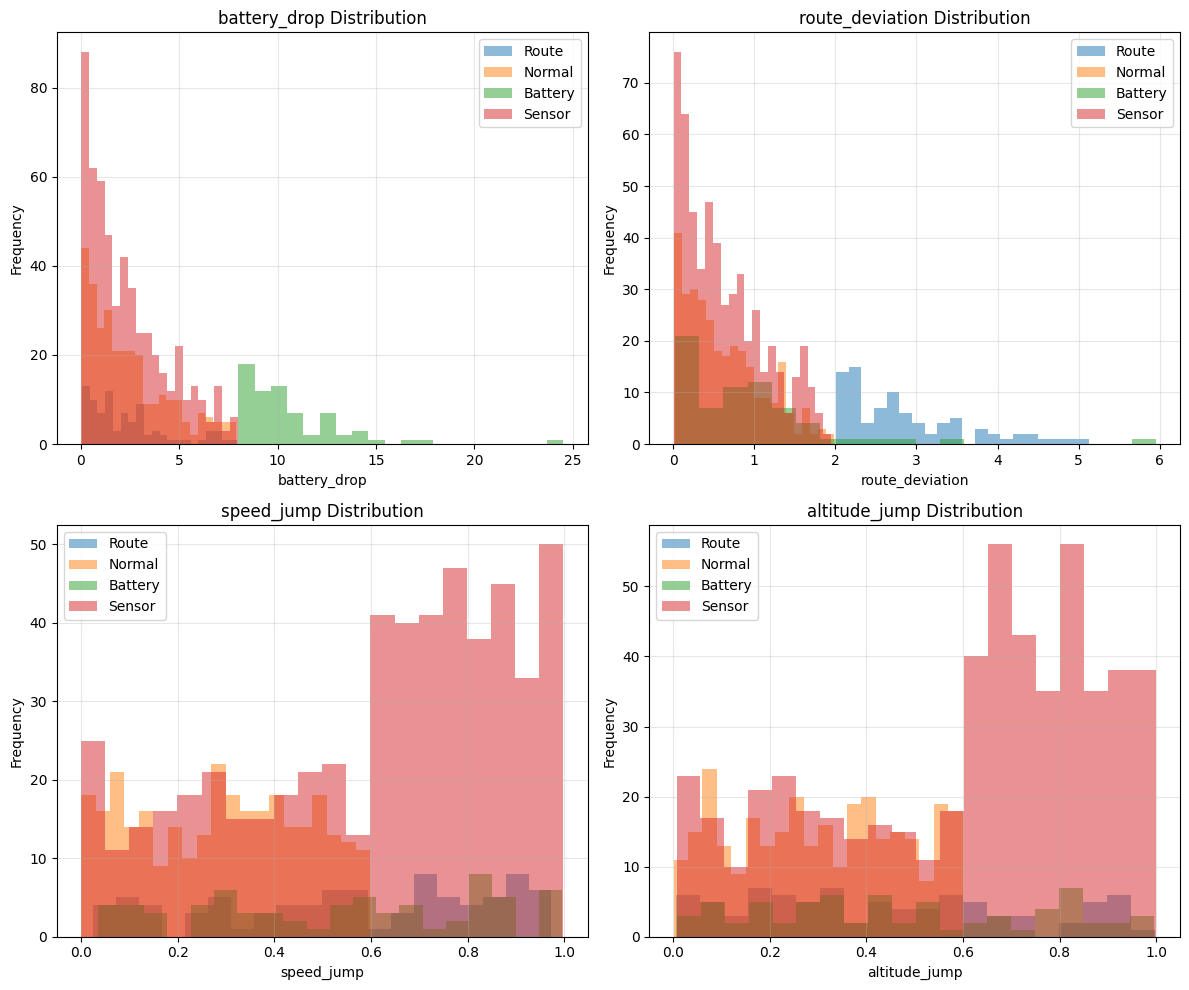

In [6]:
# Visualize feature distributions by class
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['battery_drop', 'route_deviation', 'speed_jump', 'altitude_jump']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    for label in set(y):
        mask = y == label
        ax.hist(X.loc[mask, feature], alpha=0.5, label=label, bins=20)
    ax.set_title(f'{feature} Distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3: Split Data

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())

Training set: 800 samples
Test set: 200 samples

Training class distribution:
Sensor     435
Normal     243
Route       68
Battery     54
Name: count, dtype: int64


## Step 4: Train Classifiers

In [8]:
# Model 1: Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print(f"  Accuracy: {dt_accuracy:.4f}")
print(f"\n  Confusion Matrix:")
dt_cm = confusion_matrix(y_test, y_pred_dt, labels=sorted(set(y)))
print(dt_cm)
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results:
  Accuracy: 0.9950

  Confusion Matrix:
[[ 14   0   0   0]
 [  0  59   1   0]
 [  0   0  17   0]
 [  0   0   0 109]]

  Classification Report:
              precision    recall  f1-score   support

     Battery       1.00      1.00      1.00        14
      Normal       1.00      0.98      0.99        60
       Route       0.94      1.00      0.97        17
      Sensor       1.00      1.00      1.00       109

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [9]:
# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"\n  Confusion Matrix:")
rf_cm = confusion_matrix(y_test, y_pred_rf, labels=sorted(set(y)))
print(rf_cm)
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Choose best model
best_model = rf_model if rf_accuracy > dt_accuracy else dt_model
best_model_name = "Random Forest" if rf_accuracy > dt_accuracy else "Decision Tree"
print(f"\nBest model: {best_model_name} (Accuracy: {max(rf_accuracy, dt_accuracy):.4f})")

Random Forest Results:
  Accuracy: 0.9950

  Confusion Matrix:
[[ 14   0   0   0]
 [  0  59   1   0]
 [  0   0  17   0]
 [  0   0   0 109]]

  Classification Report:
              precision    recall  f1-score   support

     Battery       1.00      1.00      1.00        14
      Normal       1.00      0.98      0.99        60
       Route       0.94      1.00      0.97        17
      Sensor       1.00      1.00      1.00       109

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200


Best model: Decision Tree (Accuracy: 0.9950)


## Step 5: Feature Importance

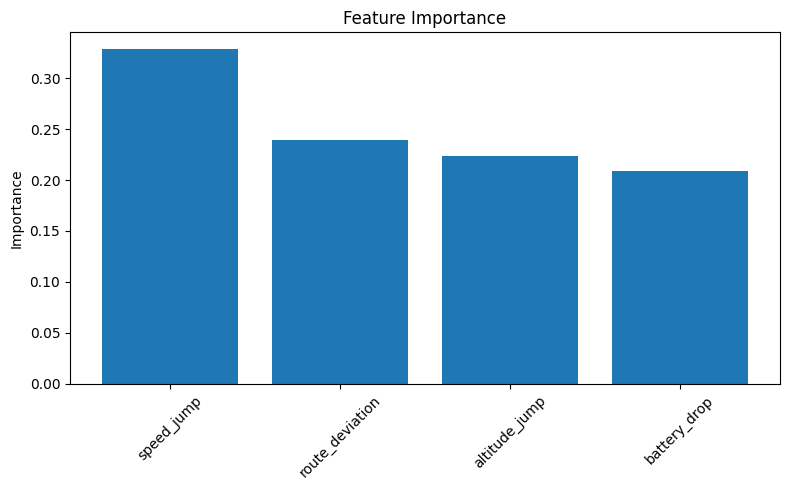

Feature Importance:
  speed_jump: 0.3287
  route_deviation: 0.2391
  altitude_jump: 0.2237
  battery_drop: 0.2084


In [10]:
# Feature importance from Random Forest
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    fig, ax = plt.subplots(figsize=(8, 5))
    indices = np.argsort(importances)[::-1]
    ax.bar(range(len(importances)), importances[indices])
    ax.set_xticks(range(len(importances)))
    ax.set_xticklabels([feature_names[i] for i in indices], rotation=45)
    ax.set_title('Feature Importance')
    ax.set_ylabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("Feature Importance:")
    for i in indices:
        print(f"  {feature_names[i]}: {importances[i]:.4f}")

## Step 6: Generate Predictions for Simulation

In [11]:
# Generate anomaly predictions for a simulated 20-step flight of 5 drones
# This demonstrates what the simulator will call during the actual run

np.random.seed(42)
n_drones = 5
n_steps = 20

# Simulate drone telemetry
predictions_list = []

for drone_id in range(n_drones):
    drone_name = f"D{drone_id + 1}"
    
    for step in range(n_steps):
        # Generate telemetry features
        battery_drop_val = np.random.exponential(scale=2)
        route_deviation_val = np.random.exponential(scale=0.7)
        speed_jump_val = np.random.uniform(0, 1)
        altitude_jump_val = np.random.uniform(0, 1)
        
        # Create feature vector
        features = pd.DataFrame([{
            'battery_drop': battery_drop_val,
            'route_deviation': route_deviation_val,
            'speed_jump': speed_jump_val,
            'altitude_jump': altitude_jump_val
        }])
        
        # Predict anomaly label
        label = best_model.predict(features)[0]
        confidence = best_model.predict_proba(features).max()
        
        predictions_list.append({
            'drone_id': drone_name,
            'step': step,
            'label': label,
            'confidence': confidence
        })

predictions_df = pd.DataFrame(predictions_list)
print(f"Generated {len(predictions_df)} predictions")
print(f"\nLabel distribution:")
print(predictions_df['label'].value_counts())
print(f"\nFirst 10 predictions:")
print(predictions_df.head(10))

Generated 100 predictions

Label distribution:
label
Sensor    59
Normal    34
Route      7
Name: count, dtype: int64

First 10 predictions:
  drone_id  step   label  confidence
0       D1     0   Route         1.0
1       D1     1  Sensor         1.0
2       D1     2  Sensor         1.0
3       D1     3  Normal         1.0
4       D1     4  Normal         1.0
5       D1     5  Normal         1.0
6       D1     6  Normal         1.0
7       D1     7  Sensor         1.0
8       D1     8   Route         1.0
9       D1     9  Sensor         1.0


## Step 7: Save CSV

In [12]:
# Save anomaly predictions to CSV
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "anomaly_predictions.csv")

predictions_df.to_csv(output_file, index=False)

print(f"Saved anomaly predictions to {output_file}")
print(f"\nFile preview:")
anomaly_df = pd.read_csv(output_file)
print(anomaly_df.head(15))

Saved anomaly predictions to ../data/processed/anomaly_predictions.csv

File preview:
   drone_id  step   label  confidence
0        D1     0   Route         1.0
1        D1     1  Sensor         1.0
2        D1     2  Sensor         1.0
3        D1     3  Normal         1.0
4        D1     4  Normal         1.0
5        D1     5  Normal         1.0
6        D1     6  Normal         1.0
7        D1     7  Sensor         1.0
8        D1     8   Route         1.0
9        D1     9  Sensor         1.0
10       D1    10  Sensor         1.0
11       D1    11  Normal         1.0
12       D1    12  Sensor         1.0
13       D1    13  Sensor         1.0
14       D1    14  Normal         1.0


## Summary

**Classifier Performance:**
- Decision Tree: Accuracy={:.4f}
- Random Forest: Accuracy={:.4f}
- **Selected Model:** {}

**Output:** Saved `anomaly_predictions.csv` with {:.0f} predictions across {} drones and {} steps.

This CSV is consumed by the simulator and visualization modules.

: {
: {
: 
3
,
: 
,
: 

: {
: 
,
: 
3.1

: 4,
: 4